In [ ]:
import kagglehub
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.


In [ ]:
print(path)

/kaggle/input/lgg-mri-segmentation


In [ ]:
import os
os.listdir(path)

['kaggle_3m', 'lgg-mri-segmentation']

In [ ]:
print(os.listdir(os.path.join(path, "lgg-mri-segmentation")))

['kaggle_3m']


In [ ]:
# system libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from glob import glob

# deep learning libraries
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [ ]:
def create_df(data_dir):
    images_paths = []
    masks_paths = glob(f'{data_dir}/*/*_mask*')

    for i in masks_paths:
        images_paths.append(i.replace('_mask', ''))

    df = pd.DataFrame(data= {'images_paths': images_paths, 'masks_paths': masks_paths})

    return df

# dataframe'i train, validation, test olarak ayirma
def split_df(df):
    # train_df olsuturma
    train_df, dummy_df = train_test_split(df, train_size= 0.8)

    # valid_df ve test_df olusturma
    valid_df, test_df = train_test_split(dummy_df, train_size= 0.5)

    return train_df, valid_df, test_df

In [ ]:
def create_gens(df, aug_dict, batch_size=16):
    img_size = (256, 256)

    img_gen = ImageDataGenerator(**aug_dict)
    msk_gen = ImageDataGenerator(**aug_dict)

    image_gen = img_gen.flow_from_dataframe(
        df, x_col='images_paths', class_mode=None, color_mode='rgb',
        target_size=img_size, batch_size=batch_size, seed=1)

    mask_gen = msk_gen.flow_from_dataframe(
        df, x_col='masks_paths', class_mode=None, color_mode='grayscale',
        target_size=img_size, batch_size=batch_size, seed=1)

    gen = zip(image_gen, mask_gen)

    for (img, msk) in gen:
        # normalizasyon ve esikleme
        img = img / 255.0
        msk = msk / 255.0
        msk[msk > 0.5] = 1
        msk[msk <= 0.5] = 0
        yield (img, msk)

In [ ]:
def unet(input_size=(256, 256, 3)):
    inputs = Input(input_size)

    # ENCODER

    # blok 1
    c1 = Conv2D(32, (3, 3), padding="same")(inputs)
    c1 = Activation("relu")(c1)
    c1 = Conv2D(32, (3, 3), padding="same")(c1)
    c1 = BatchNormalization(axis=3)(c1)
    c1 = Activation("relu")(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # blok 2
    c2 = Conv2D(64, (3, 3), padding="same")(p1)
    c2 = Activation("relu")(c2)
    c2 = Conv2D(64, (3, 3), padding="same")(c2)
    c2 = BatchNormalization(axis=3)(c2)
    c2 = Activation("relu")(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # blok 3
    c3 = Conv2D(128, (3, 3), padding="same")(p2)
    c3 = Activation("relu")(c3)
    c3 = Conv2D(128, (3, 3), padding="same")(c3)
    c3 = BatchNormalization(axis=3)(c3)
    c3 = Activation("relu")(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # bottleneck - bridge
    c4 = Conv2D(256, (3, 3), padding="same")(p3)
    c4 = Activation("relu")(c4)
    c4 = Conv2D(256, (3, 3), padding="same")(c4)
    c4 = BatchNormalization(axis=3)(c4)
    c4 = Activation("relu")(c4)

    # DECODER

    # blok 5
    u5_up = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(c4)
    u5_merge = concatenate([u5_up, c3])
    u5 = Conv2D(128, (3, 3), padding="same")(u5_merge)
    u5 = Activation("relu")(u5)
    u5 = Conv2D(128, (3, 3), padding="same")(u5)
    u5 = BatchNormalization(axis=3)(u5)
    u5 = Activation("relu")(u5)

    # blok 6
    u6_up = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(u5)
    u6_merge = concatenate([u6_up, c2])
    u6 = Conv2D(64, (3, 3), padding="same")(u6_merge)
    u6 = Activation("relu")(u6)
    u6 = Conv2D(64, (3, 3), padding="same")(u6)
    u6 = BatchNormalization(axis=3)(u6)
    u6 = Activation("relu")(u6)

    # blok 7
    u7_up = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(u6)
    u7_merge = concatenate([u7_up, c1])
    u7 = Conv2D(32, (3, 3), padding="same")(u7_merge)
    u7 = Activation("relu")(u7)
    u7 = Conv2D(32, (3, 3), padding="same")(u7)
    u7 = BatchNormalization(axis=3)(u7)
    u7 = Activation("relu")(u7)

    # cikis katmani
    outputs = Conv2D(1, (1, 1), activation="sigmoid")(u7)

    return Model(inputs=[inputs], outputs=[outputs])

In [ ]:
def dice_coef(y_true, y_pred, smooth=100):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)

    intersection = K.sum(y_true_flatten * y_pred_flatten)
    union = K.sum(y_true_flatten) + K.sum(y_pred_flatten)
    return (2 * intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred, smooth=100):
    return -dice_coef(y_true, y_pred, smooth)

def iou_coef(y_true, y_pred, smooth=100):
    intersection = K.sum(y_true * y_pred)
    sum = K.sum(y_true + y_pred)
    iou = (intersection + smooth) / (sum - intersection + smooth)
    return iou

In [ ]:
def plot_training(hist):
    tr_acc = hist.history['accuracy']
    tr_iou = hist.history['iou_coef']
    tr_dice = hist.history['dice_coef']
    tr_loss = hist.history['loss']

    val_acc = hist.history['val_accuracy']
    val_iou = hist.history['val_iou_coef']
    val_dice = hist.history['val_dice_coef']
    val_loss = hist.history['val_loss']

    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    index_iou = np.argmax(val_iou)
    iou_highest = val_iou[index_iou]
    index_dice = np.argmax(val_dice)
    dice_highest = val_dice[index_dice]
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]

    Epochs = [i+1 for i in range(len(tr_acc))]

    acc_label = f'best epoch= {str(index_acc + 1)}'
    iou_label = f'best epoch= {str(index_iou + 1)}'
    dice_label = f'best epoch= {str(index_dice + 1)}'
    loss_label = f'best epoch= {str(index_loss + 1)}'

    # Plot training history
    plt.figure(figsize= (12, 12))
    plt.style.use('fivethirtyeight')

    # Training Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Training IoU
    plt.subplot(2, 2, 2)
    plt.plot(Epochs, tr_iou, 'r', label= 'Training IoU')
    plt.plot(Epochs, val_iou, 'g', label= 'Validation IoU')
    plt.scatter(index_iou + 1 , iou_highest, s= 150, c= 'blue', label= iou_label)
    plt.title('Training and Validation IoU Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    # Training Dice
    plt.subplot(2, 2, 3)
    plt.plot(Epochs, tr_dice, 'r', label= 'Training Dice')
    plt.plot(Epochs, val_dice, 'g', label= 'Validation Dice')
    plt.scatter(index_dice + 1 , dice_highest, s= 150, c= 'blue', label= dice_label)
    plt.title('Training and Validation Dice Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('Dice')
    plt.legend()

    # Training Loss
    plt.subplot(2, 2, 4)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def show_images(images, masks):
    plt.figure(figsize=(12, 12))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        img_path = images[i]
        mask_path = masks[i]
        # read image and convert it to RGB scale
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # read mask
        mask = cv2.imread(mask_path)
        # show image and mask
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)

        plt.axis('off')

    plt.tight_layout()
    plt.show()

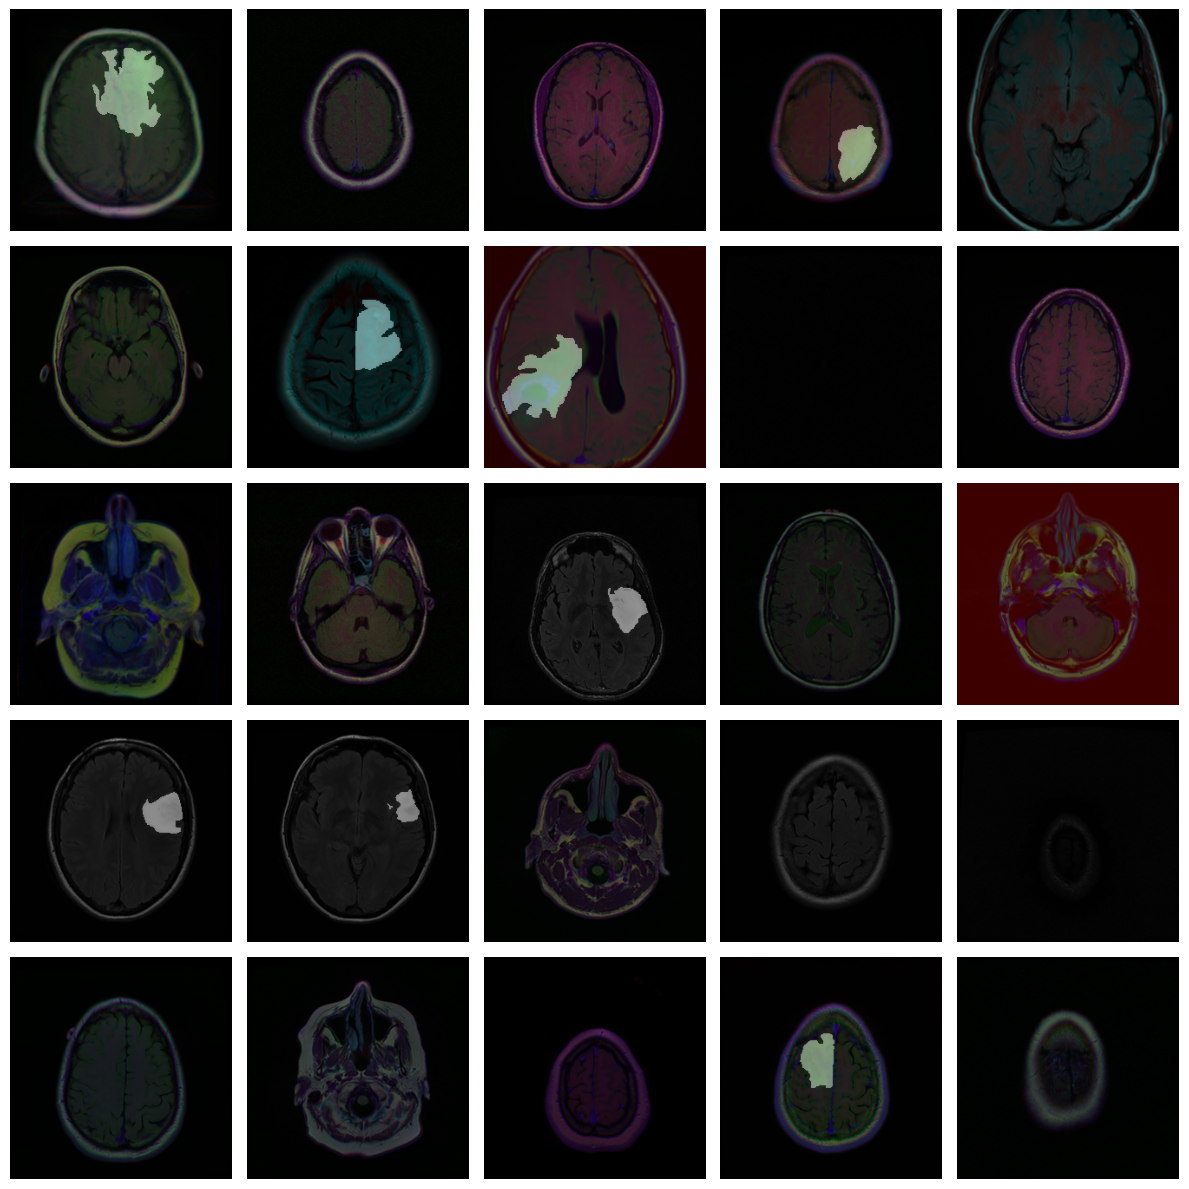

In [ ]:
data_dir = '/kaggle/input/lgg-mri-segmentation/kaggle_3m'

df = create_df(data_dir)
train_df, valid_df, test_df = split_df(df)


tr_aug_dict = dict(rotation_range=0.2,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            horizontal_flip=True,
                            fill_mode='nearest')


train_gen = create_gens(train_df, aug_dict=tr_aug_dict)
valid_gen = create_gens(valid_df, aug_dict={})
test_gen = create_gens(test_df, aug_dict={})

show_images(list(train_df['images_paths']), list(train_df['masks_paths']))

In [ ]:
model = unet()
model.compile(Adamax(learning_rate= 0.001), loss= dice_loss, metrics= ['accuracy', iou_coef, dice_coef])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_4[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]  

 Total params: 1,928,417 (7.36 MB)

 Trainable params: 1,927,009 (7.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


callbacks = [
    ModelCheckpoint('unet.keras', verbose=1, save_best_only=True),

    EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True),

    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, min_lr=1e-7)
]

epochs = 60
batch_size = 16

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_df) // batch_size,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen,
    validation_steps=len(valid_df) // batch_size
)

Found 3143 validated image filenames.
Found 3143 validated image filenames.
Epoch 1/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8676 - dice_coef: 0.0805 - iou_coef: 0.0428 - loss: -0.0805Found 393 validated image filenames.
Found 393 validated image filenames.

Epoch 1: val_loss improved from inf to -0.01696, saving model to unet.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 149s 571ms/step - accuracy: 0.8679 - dice_coef: 0.0806 - iou_coef: 0.0429 - loss: -0.0806 - val_accuracy: 0.9903 - val_dice_coef: 0.0170 - val_iou_coef: 0.0089 - val_loss: -0.0170 - learning_rate: 0.0010
Epoch 2/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9856 - dice_coef: 0.2476 - iou_coef: 0.1465 - loss: -0.2486
Epoch 2: val_loss improved from -0.01696 to -0.26920, saving model to unet.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 110s 434ms/step - accuracy: 0.9857 - dice_coef: 0.2479 - iou_coef: 0.1467 - loss: -0.2489 - val_accuracy: 0.9889 - val_dice_coef: 0.2692 - val_iou_coef: 0.1629 - val_loss: -0.

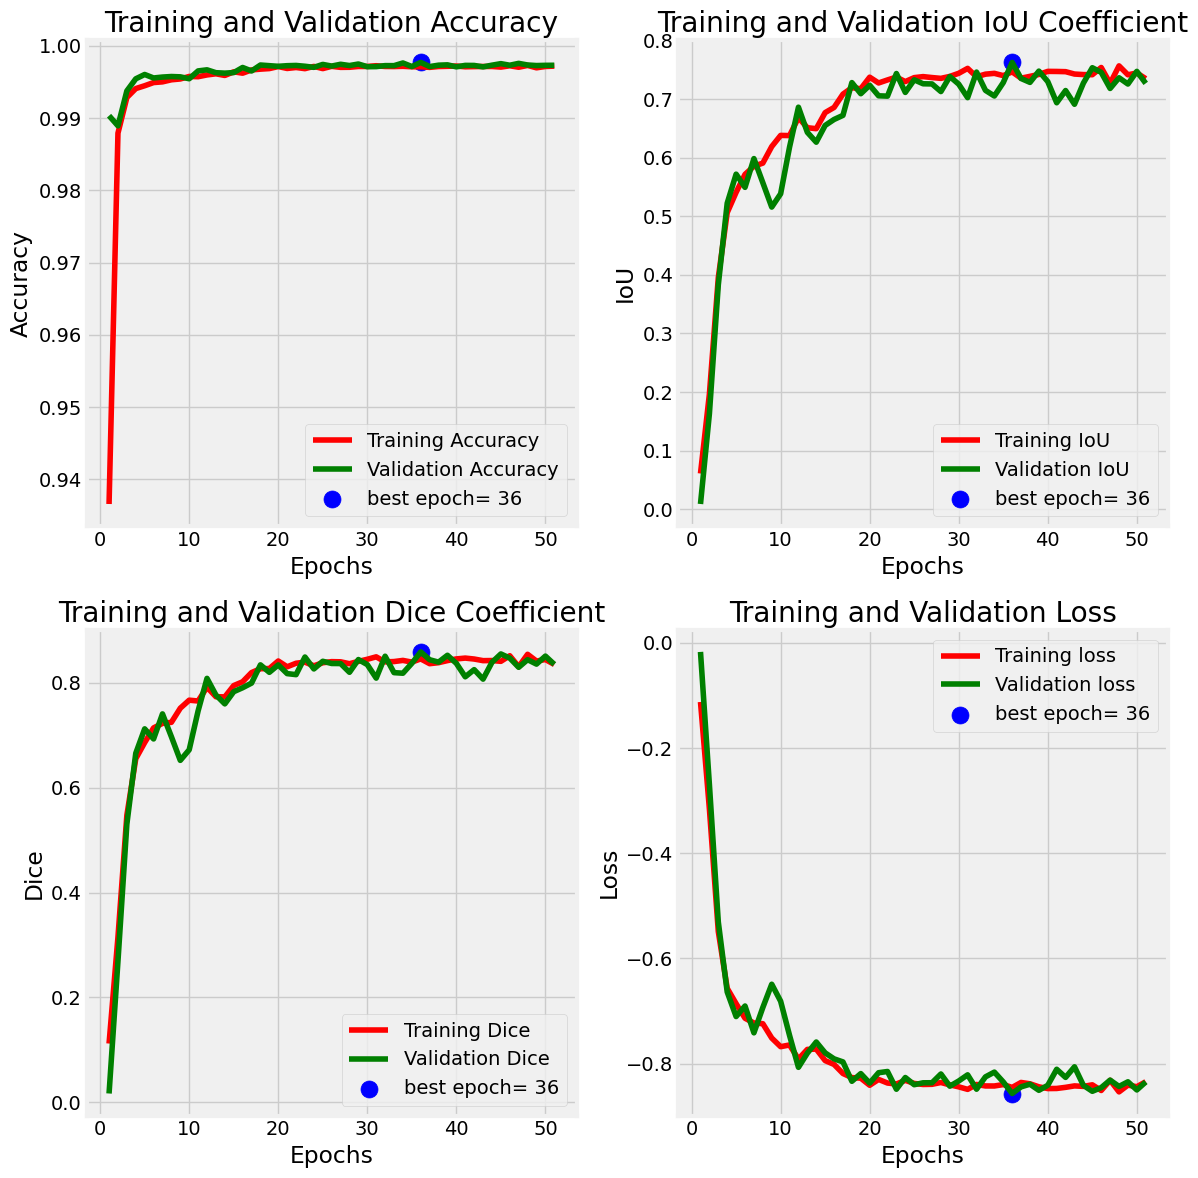

In [ ]:
plot_training(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


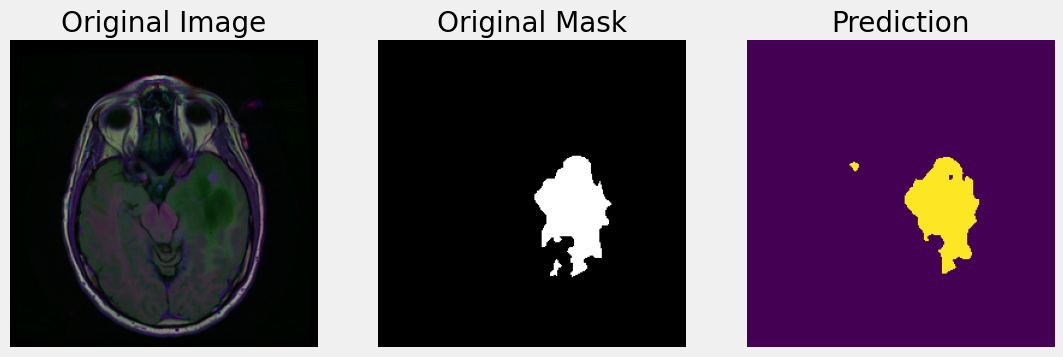

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


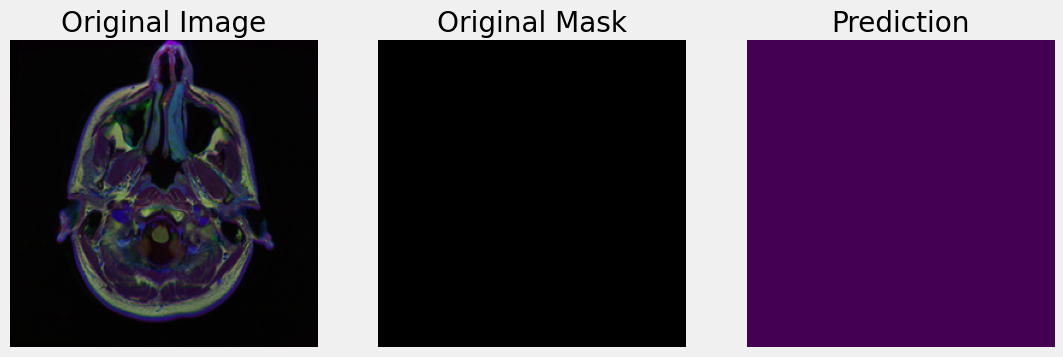

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


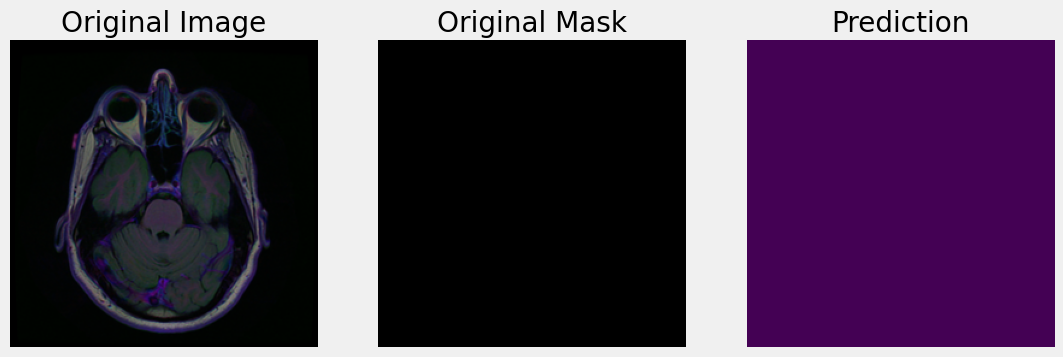

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


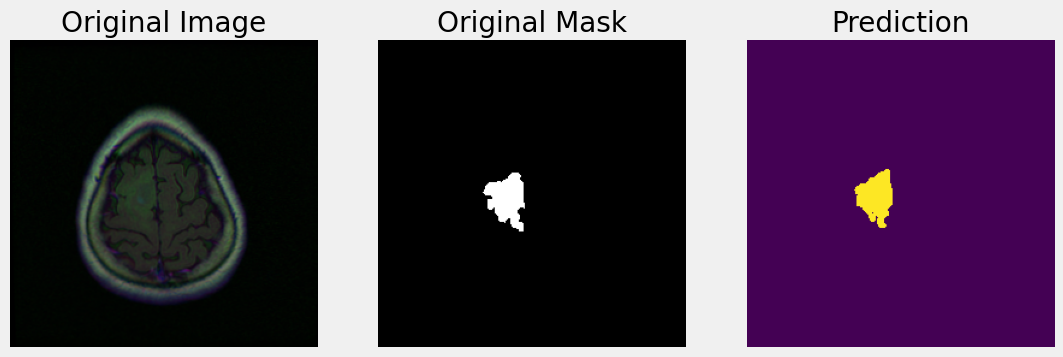

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


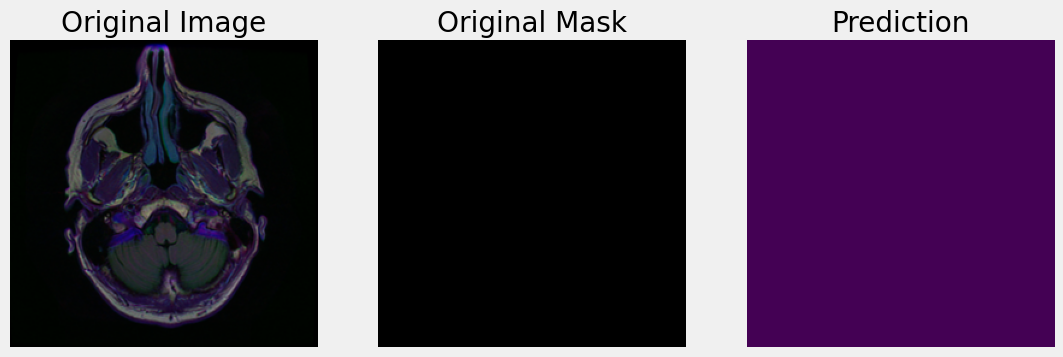

In [ ]:
for _ in range(5):
    index = np.random.randint(0, len(test_df))
    img = cv2.imread(test_df['images_paths'].iloc[index])
    img = cv2.resize(img, (256, 256))
    img = (img / 255).astype('float32')
    img = img[np.newaxis, :, :, : ]

    predicted_img = model.predict(img)

    plt.figure(figsize=(12, 12))

    # orijinal
    plt.subplot(1, 3, 1)
    img_plot = cv2.cvtColor(np.squeeze(img), cv2.COLOR_BGR2RGB)
    plt.imshow(img_plot)
    plt.axis('off')
    plt.title('Original Image')

    # maske
    plt.subplot(1, 3, 2)
    mask = cv2.imread(test_df['masks_paths'].iloc[index], cv2.IMREAD_GRAYSCALE)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.title('Original Mask')

    # tahmin
    plt.subplot(1, 3, 3)
    plt.imshow(np.squeeze(predicted_img) > 0.5)
    plt.axis('off')
    plt.title('Prediction')

    plt.show()